SECTION 1 — GRID DEMAND MODEL

In [158]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [159]:
data = pd.read_excel("hourlyLoadDataIndia.xlsx")

data["datetime"] = pd.to_datetime(data["datetime"])
data = data.sort_values("datetime").reset_index(drop=True)

In [161]:
data["hour"] = data["datetime"].dt.hour
data["dayofweek"] = data["datetime"].dt.dayofweek
data["month"] = data["datetime"].dt.month

In [162]:
data["lag1"] = data["National Hourly Demand"].shift(1)
data["lag24"] = data["National Hourly Demand"].shift(24)
data["lag168"] = data["National Hourly Demand"].shift(168)

data = data.dropna().reset_index(drop=True)

In [163]:
features = ["hour","dayofweek","month","lag1","lag24","lag168"]

X = data[features]
y = data["National Hourly Demand"]

split = int(0.8 * len(data))

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [164]:
demand_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

demand_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [165]:
pred = demand_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 2617.2989902477984
RMSE: 4287.644057381465
R2: 0.9518974610128482


In [166]:
joblib.dump(demand_model,"demand_model.pkl")

['demand_model.pkl']

SECTION 2 — PRICE MODEL

In [167]:
data = pd.read_csv("India_energy_weather (1).csv")

data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time").reset_index(drop=True)

data["hour"] = data["time"].dt.hour
data["month"] = data["time"].dt.month
data["dayofweek"] = data["time"].dt.dayofweek

In [168]:
# ---------------- INDIA DOMAIN FEATURES ----------------

# Weekend effect (lower industrial load)
data["is_weekend"] = data["dayofweek"].isin([5,6]).astype(int)

# Summer peak (AC demand spike: Apr–Jul)
data["summer_peak"] = ((data["month"]>=4) & (data["month"]<=7)).astype(int)

# Rolling price (shifted to avoid leakage)
data["price_rolling_24"] = (
    data["price_day_ahead_INR"]
    .shift(1)
    .rolling(24)
    .mean()
)

data["price_lag24"] = data["price_day_ahead_INR"].shift(24)

demand_model = joblib.load("demand_model.pkl")

data["lag1"] = data["total load forecast"].shift(1)
data["lag24"] = data["total load forecast"].shift(24)
data["lag168"] = data["total load forecast"].shift(168)

data = data.dropna().reset_index(drop=True)

demand_features = ["hour","dayofweek","month","lag1","lag24","lag168"]

data["demand_pred"] = demand_model.predict(data[demand_features])

In [169]:

price_features = [
    "WS_10m",
    "Temp_2m",
    "hour",
    "month",
    "is_weekend",
    "summer_peak",
    "price_rolling_24",
    "demand_pred"
]

X = data[price_features]
y = data["price_day_ahead_INR"]

split = int(0.8*len(data))

Xp_train = X.iloc[:split]
Xp_test  = X.iloc[split:]

yp_train = y.iloc[:split]
yp_test  = y.iloc[split:]

In [170]:
price_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

price_model.fit(Xp_train, yp_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [171]:
pred_price = price_model.predict(Xp_test)

print("Price MAE:", mean_absolute_error(yp_test,pred_price))
print("Price RMSE:", np.sqrt(mean_squared_error(yp_test,pred_price)))
print("Price R2:", r2_score(yp_test,pred_price))

Price MAE: 740.7001620566554
Price RMSE: 1020.634213803142
Price R2: 0.5437263843101754


In [172]:
joblib.dump(price_model,"price_model.pkl")

['price_model.pkl']

SECTION 3 — ENERGY LOSS RISK MODEL

In [173]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [174]:
data = pd.read_csv("India_energy_weather (1).csv")
print(data.columns)

data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time").reset_index(drop=True)

data["hour"] = data["time"].dt.hour
data["month"] = data["time"].dt.month
data["dayofweek"] = data["time"].dt.dayofweek

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind onshore day ahead', 'total load forecast',
       'total load actual', 'price_day_ahead_INR', 'price_actual_INR',
       'Unnamed: 0', 'Location', 'Temp_2m', 'RelHum_2m', 'DP_2m', 'WS_10m',
       'WS_100m', 'WD_10m', 'WD_100m', 'WG_10m'],
      dtype='object')


In [175]:
# Create lag features using total load forecast as proxy

data["lag1"] = data["total load forecast"].shift(1)
data["lag24"] = data["total load forecast"].shift(24)
data["lag168"] = data["total load forecast"].shift(168)

# Drop NaNs caused by shifting
data = data.dropna().reset_index(drop=True)

In [176]:
demand_model = joblib.load("demand_model.pkl")
price_model = joblib.load("price_model.pkl")

In [177]:
# ===== ENSURE INDIA DOMAIN FEATURES EXIST =====

# Weekend flag
data["is_weekend"] = data["dayofweek"].isin([5,6]).astype(int)

# Summer peak (Apr–Jul)
data["summer_peak"] = ((data["month"]>=4) & (data["month"]<=7)).astype(int)

# Rolling price (shifted to avoid leakage)
data["price_rolling_24"] = (
    data["price_day_ahead_INR"]
    .shift(1)
    .rolling(24)
    .mean()
)

# Drop rows created by rolling
data = data.dropna().reset_index(drop=True)

In [178]:
demand_features = ["hour","dayofweek","month","lag1","lag24","lag168"]
data["demand_pred"] = demand_model.predict(data[demand_features])

price_features = [
    "WS_10m",
    "Temp_2m",
    "hour",
    "month",
    "is_weekend",
    "summer_peak",
    "price_rolling_24",
    "demand_pred"
]
data["price_pred"] = price_model.predict(data[price_features])


In [179]:
curt = pd.read_csv("caiso_curtailment.csv")
print(curt.columns)



Index(['Unnamed: 0', 'OUTAGE MRID', 'RESOURCE NAME', 'Unnamed: 3',
       'RESOURCE ID', 'OUTAGE TYPE', 'NATURE OF WORK',
       'CURTAILMENT START DATE TIME', 'CURTAILMENT END DATE TIME',
       'CURTAILMENT MW', 'RESOURCE PMAX MW', 'Unnamed: 11',
       'NET QUALIFYING CAPACITY MW'],
      dtype='object')


In [180]:
# Look at first 10 raw timestamps
curt["CURTAILMENT START DATE TIME"].head(10)

,CURTAILMENT START DATE TIME
0,2022-12-24 00:00:00
1,2022-12-31 23:59:00
2,2022-12-30 12:00:00
3,2022-12-14 00:00:00
4,2022-12-30 07:00:00
5,2022-12-31 00:00:00
6,2023-01-01 00:00:00
7,2022-12-31 00:00:00
8,2023-01-01 00:00:00
9,2022-12-31 18:17:00


In [181]:
curt["CURTAILMENT START DATE TIME"] = pd.to_datetime(
    curt["CURTAILMENT START DATE TIME"],
    errors="coerce"
)

# Check how many failed
curt["CURTAILMENT START DATE TIME"].isna().sum()

np.int64(364)

In [182]:
curt = curt.dropna(subset=["CURTAILMENT START DATE TIME"]).reset_index(drop=True)

print("Rows after cleanup:", len(curt))

Rows after cleanup: 672206


In [183]:
# Floor to hour
curt["hour"] = curt["CURTAILMENT START DATE TIME"].dt.floor("H")

# Aggregate curtailment MW per hour
hourly_curt = (
    curt.groupby("hour")["CURTAILMENT MW"]
    .sum()
    .reset_index()
    .rename(columns={"CURTAILMENT MW": "curtailment_mw"})
)

hourly_curt.head()

/tmp/ipython-input-273/3125082442.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  curt["hour"] = curt["CURTAILMENT START DATE TIME"].dt.floor("H")


,hour,curtailment_mw
0,2021-05-07 00:00:00,2.52.52.52.52.52.52.52.52.52.52.52.52.52.52.52...
1,2021-07-29 00:00:00,0.80.80.80.80.80.80.80.80.80.80.80.80.80.80.80...
2,2022-01-01 00:00:00,5.75
3,2022-02-28 23:00:00,0.5
4,2022-03-14 19:00:00,3333333333333333333333333333333333333333333333...


In [184]:
# Convert to numeric (force bad values to NaN)
curt["CURTAILMENT MW"] = pd.to_numeric(
    curt["CURTAILMENT MW"],
    errors="coerce"
)

# Check how many failed
print("Invalid MW values:", curt["CURTAILMENT MW"].isna().sum())

Invalid MW values: 0


In [185]:
# Round timestamps to hour
curt["hour"] = curt["CURTAILMENT START DATE TIME"].dt.floor("h")

# Aggregate MW per hour
curt_hourly = (
    curt.groupby("hour")["CURTAILMENT MW"]
    .sum()
    .reset_index()
)

# Rename column
curt_hourly = curt_hourly.rename(columns={"CURTAILMENT MW": "curtailment_mw"})

# Inspect
curt_hourly.head()

,hour,curtailment_mw
0,2021-05-07 00:00:00,912.50
1,2021-07-29 00:00:00,292.00
2,2022-01-01 00:00:00,5.75
3,2022-02-28 23:00:00,0.50
4,2022-03-14 19:00:00,165.00


In [186]:
curt_hourly.describe()

,hour,curtailment_mw
count,8917,8917.000000
mean,2023-06-28 14:54:40.654928640,2387.348008
min,2021-05-07 00:00:00,0.020000
25%,2023-03-28 07:00:00,1471.900000
50%,2023-06-29 04:00:00,2035.480000
75%,2023-09-30 01:00:00,2783.360000
max,2023-12-31 22:00:00,87965.910000
std,NaN,2243.912766


In [187]:
# Extract hour-of-day (0–23)
curt_hourly["hour_of_day"] = curt_hourly["hour"].dt.hour

# Average curtailment per hour-of-day
hour_profile = (
    curt_hourly.groupby("hour_of_day")["curtailment_mw"]
    .mean()
    .reset_index()
)

# Normalize to 0–1 scale (risk score)
hour_profile["curtail_score"] = (
    hour_profile["curtailment_mw"] /
    hour_profile["curtailment_mw"].max()
)

hour_profile

,hour_of_day,curtailment_mw,curtail_score
0,0,5780.293514,1.000000
1,1,1772.456757,0.306638
2,2,1409.936192,0.243921
3,3,1415.177260,0.244828
4,4,1510.801553,0.261371
5,5,2318.922391,0.401177
6,6,2086.065422,0.360893
7,7,2241.810027,0.387837
8,8,2261.212791,0.391193
9,9,2003.143495,0.346547


In [188]:
# Prepare mapping table
hour_map = hour_profile[["hour_of_day","curtail_score"]].rename(
    columns={"hour_of_day":"hour"}
)

# Merge into India dataset
data = data.merge(hour_map, on="hour", how="left")

# Fill missing with zero
data["curtail_score"] = data["curtail_score"].fillna(0)

In [189]:
# True energy loss (from historical dataset)
data["energy_loss"] = (
    data["forecast wind onshore day ahead"]
    - data["generation wind onshore"]
).clip(lower=0)




In [190]:
# Cap extreme spikes
cap = data["energy_loss"].quantile(0.99)
data["energy_loss"] = data["energy_loss"].clip(upper=cap)

# Log transform for regression stability
data["log_loss"] = np.log1p(data["energy_loss"])

#High loss = top 25%
threshold = data["energy_loss"].quantile(0.75)
data["high_loss"] = (data["energy_loss"] > threshold).astype(int)

# Wind volatility (grid instability proxy)
data["wind_volatility"] = data["WS_10m"].rolling(6).std()

# Demand–generation stress
data["stress"] = data["forecast wind onshore day ahead"] / (data["demand_pred"] + 1)

# Evening congestion proxy
data["evening_peak"] = ((data["hour"] >= 18) & (data["hour"] <= 22)).astype(int)

# Demand rolling average
data["demand_roll"] = data["demand_pred"].rolling(6).mean()

data = data.dropna().reset_index(drop=True)

In [191]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

loss_features = [
    "forecast wind onshore day ahead",
    "WS_10m",
    "Temp_2m",
    "hour",
    "month",
    "demand_pred",
    "wind_volatility",
    "demand_roll",
    "stress",
    "evening_peak"
]



In [192]:
X_reg = data[loss_features]
y_reg = data["log_loss"]

split = int(0.8*len(data))

X_train = X_reg.iloc[:split]
X_test  = X_reg.iloc[split:]

y_train = y_reg.iloc[:split]
y_test  = y_reg.iloc[split:]

In [193]:
loss_reg_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

loss_reg_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [194]:
pred_loss = loss_reg_model.predict(X_test)

# Convert log-loss back to MW
true_loss = np.expm1(y_test)
pred_loss = np.expm1(pred_loss)

mae = mean_absolute_error(true_loss, pred_loss)
rmse = np.sqrt(mean_squared_error(true_loss, pred_loss))

print("Loss MAE:", mae)
print("Loss RMSE:", rmse)

Loss MAE: 44.25030020484713
Loss RMSE: 82.14428874026859


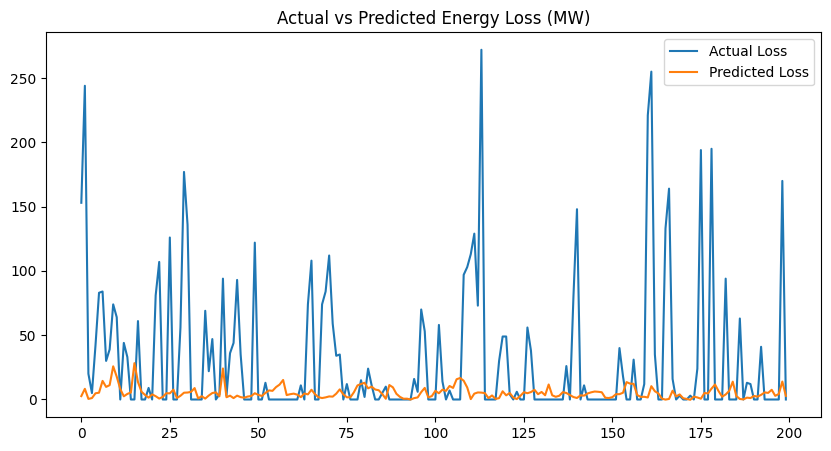

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(true_loss.values[:200],label="Actual Loss")
plt.plot(pred_loss[:200],label="Predicted Loss")
plt.legend()
plt.title("Actual vs Predicted Energy Loss (MW)")
plt.show()

In [196]:
joblib.dump(loss_reg_model, "loss_reg_model.pkl")

['loss_reg_model.pkl']

In [197]:
from xgboost import XGBRegressor

loss_reg_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:quantileerror",
    quantile_alpha=0.9   # 90th percentile = risk loss
)

loss_reg_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [198]:
pred_loss = loss_reg_model.predict(X_test)

# Convert log-loss back to MW
true_loss = np.expm1(y_test)
pred_loss = np.expm1(pred_loss)

mae = mean_absolute_error(true_loss, pred_loss)
rmse = np.sqrt(mean_squared_error(true_loss, pred_loss))

print("Loss MAE:", mae)
print("Loss RMSE:", rmse)

Loss MAE: 83.45462628144655
Loss RMSE: 96.92474264721235


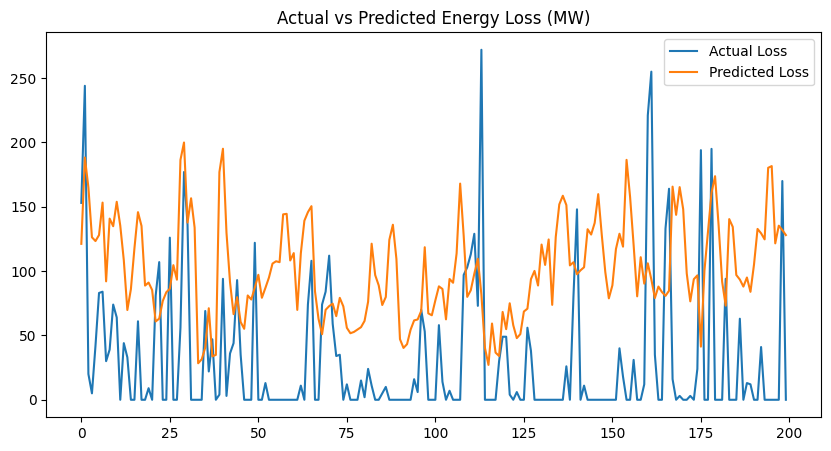

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(true_loss.values[:200],label="Actual Loss")
plt.plot(pred_loss[:200],label="Predicted Loss")
plt.legend()
plt.title("Actual vs Predicted Energy Loss (MW)")
plt.show()

In [200]:
threshold = data["energy_loss"].quantile(0.75)
data["high_loss"] = (data["energy_loss"]>threshold).astype(int)

In [201]:
# Extreme loss = top 10% (very high risk)
extreme_thresh = data["energy_loss"].quantile(0.90)
data["extreme_loss"] = (data["energy_loss"] > extreme_thresh).astype(int)

print("Extreme loss samples:", data["extreme_loss"].sum())

Extreme loss samples: 853


TimeSeries CV F1 scores: [0.3289940828402367, 0.4117053481331988, 0.42642140468227424, 0.3789279112754159, 0.4003254678600488]
Mean CV F1: 0.3892748429582349
hour                               0.153136
stress                             0.107840
evening_peak                       0.104524
demand_roll                        0.095283
Temp_2m                            0.092555
forecast wind onshore day ahead    0.092270
demand_pred                        0.091229
month                              0.088491
WS_10m                             0.088128
wind_volatility                    0.086544
dtype: float32


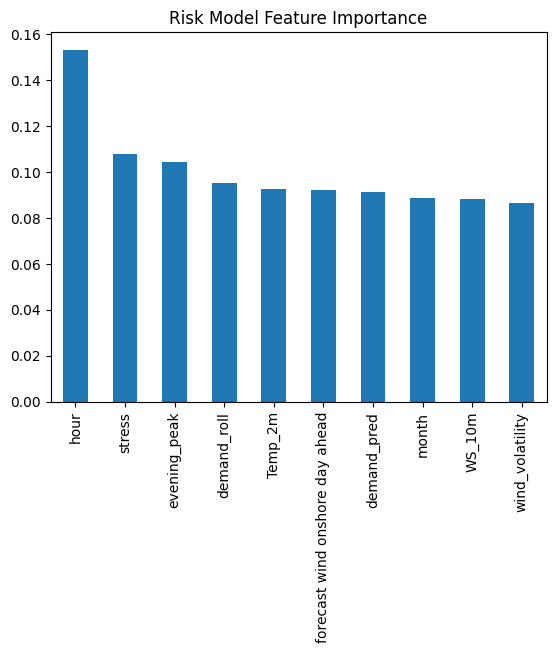

Best Threshold: 0.20000000000000004
              precision    recall  f1-score   support

           0       0.85      0.26      0.39      1322
           1       0.25      0.85      0.39       391

    accuracy                           0.39      1713
   macro avg       0.55      0.55      0.39      1713
weighted avg       0.71      0.39      0.39      1713



In [202]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

# ---------------- Data ----------------
X = data[loss_features]
y = data["high_loss"]
y_extreme = data["extreme_loss"]

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scale = (len(y_train) - y_train.sum()) / y_train.sum()

# ---------------- Main Risk Classifier ----------------
loss_clf = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric="logloss"
)

# ---------------- TimeSeries Cross Validation ----------------
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for train_idx, val_idx in tscv.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    loss_clf.fit(X_tr, y_tr)

    probs_val = loss_clf.predict_proba(X_val)[:, 1]
    preds_val = (probs_val > 0.30).astype(int)

    cv_scores.append(f1_score(y_val, preds_val))

print("TimeSeries CV F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))

# ---------------- Final Training ----------------
loss_clf.fit(X_train, y_train)
probs = loss_clf.predict_proba(X_test)[:, 1]

# ---------------- Feature Importance ----------------
fi = pd.Series(loss_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi)

fi.plot(kind="bar", title="Risk Model Feature Importance")
plt.show()

# ---------------- Threshold Optimization ----------------
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    preds = (probs > t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_t = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_t)

# ---------------- Final Prediction ----------------
pred = (probs > best_t).astype(int)

print(classification_report(y_test, pred))

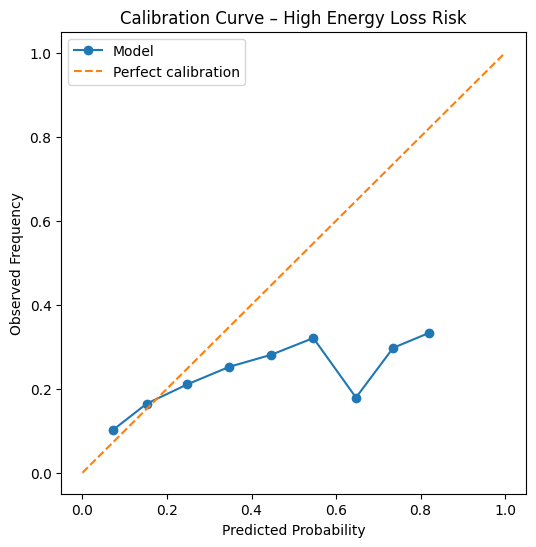

In [203]:
from sklearn.calibration import calibration_curve

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1],[0,1],'--', label="Perfect calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve – High Energy Loss Risk")
plt.legend()
plt.show()

In [204]:
# ---------------- EXTREME LOSS CLASSIFIER ----------------

# Prepare extreme labels
Xe_train, Xe_test = X[:split], X[split:]
ye_train, ye_test = y_extreme[:split], y_extreme[split:]

scale_extreme = (len(ye_train) - ye_train.sum()) / ye_train.sum()

extreme_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_extreme,
    eval_metric="logloss"
)

# Train extreme model
extreme_clf.fit(Xe_train, ye_train)

# Predict probabilities
probs_ext = extreme_clf.predict_proba(Xe_test)[:, 1]

# 🔥 Use optimized threshold from main classifier
pred_ext = (probs_ext > best_t).astype(int)

print("Extreme Loss Classification Report:")
print(classification_report(ye_test, pred_ext))

Extreme Loss Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.32      0.48      1555
           1       0.11      0.83      0.19       158

    accuracy                           0.36      1713
   macro avg       0.53      0.57      0.33      1713
weighted avg       0.87      0.36      0.45      1713



In [205]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probs)
print("ROC AUC:", auc)

ROC AUC: 0.5812223593640574


In [206]:
probs = loss_clf.predict_proba(X_test)[:,1]

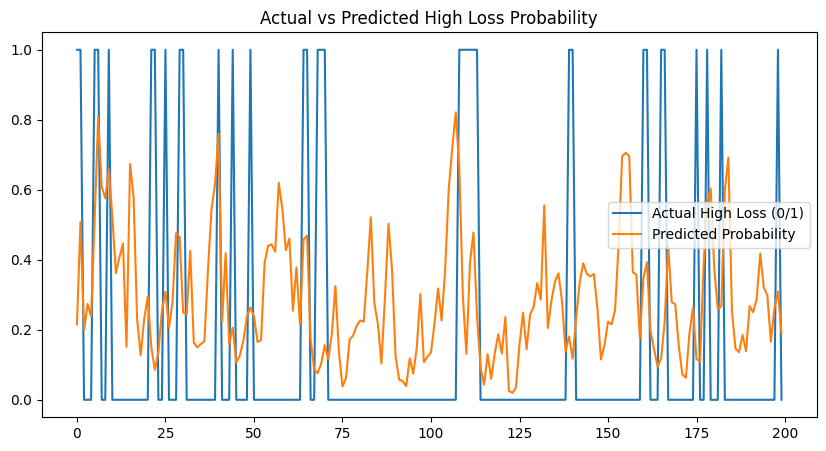

In [207]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual High Loss (0/1)")
plt.plot(probs[:200], label="Predicted Probability")

plt.legend()
plt.title("Actual vs Predicted High Loss Probability")
plt.show()

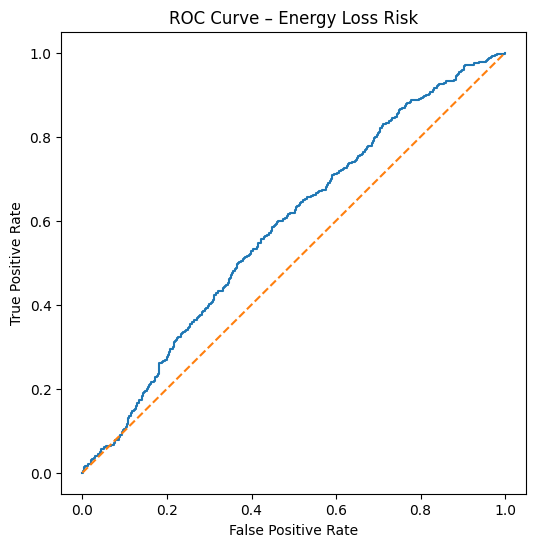

In [208]:
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(y_test, probs)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Energy Loss Risk")
plt.show()

In [209]:
from sklearn.metrics import classification_report

probs = loss_clf.predict_proba(X_test)[:,1]

# ---------- ADD HERE ----------
risk_level = pd.cut(
    probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

# Optional: attach to test dataframe
results = X_test.copy()
results["probability"] = probs
results["risk_level"] = risk_level
# --------------------------------

pred = (probs > 0.30).astype(int)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.48      0.61      1322
           1       0.27      0.64      0.38       391

    accuracy                           0.52      1713
   macro avg       0.55      0.56      0.49      1713
weighted avg       0.70      0.52      0.56      1713



In [210]:
from sklearn.metrics import balanced_accuracy_score
print("Balanced Accuracy:", balanced_accuracy_score(y_test,pred))

Balanced Accuracy: 0.5635516983877021


In [211]:
joblib.dump(loss_clf, "loss_risk_model.pkl")

['loss_risk_model.pkl']

FINAL — OPERATOR OUTPUT LOGIC

In [212]:
low_loss = (
    data[data["high_loss"]==0]["energy_loss"].mean() /
    data["forecast wind onshore day ahead"].mean()
)

high_loss = (
    data[data["high_loss"]==1]["energy_loss"].mean() /
    data["forecast wind onshore day ahead"].mean()
)

In [213]:
def interpret_risk(wind_power, price, risk_prob):

    if risk_prob < 0.3:
        level="LOW"; loss_pct=low_loss
    elif risk_prob <0.6:
        level="MEDIUM"; loss_pct=(low_loss+high_loss)/2
    else:
        level="HIGH"; loss_pct=high_loss

    loss_mw = wind_power * loss_pct
    usable = max(wind_power - loss_mw, 0)
    revenue_loss = loss_mw * price

    return {
        "risk":level,
        "loss_mw":round(loss_mw,2),
        "usable_power":round(usable,2),
        "revenue_loss":round(revenue_loss,2)
    }

In [214]:
from google.colab import files

files.download("demand_model.pkl")
files.download("price_model.pkl")
files.download("loss_risk_model.pkl")
files.download("loss_reg_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [374]:
print(X_test.shape)
print(y_test.shape)
print(sum(y_test))
print(y_test.index[:5])

(1713, 11)
(1713,)
391
RangeIndex(start=6850, stop=6855, step=1)
